In [3]:
%pip install emcee corner

     |████████████████████████████████| 47 kB 2.0 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


Success! Loaded 78 galaxies.
Sampling...


100%|██████████| 6000/6000 [00:04<00:00, 1395.21it/s]


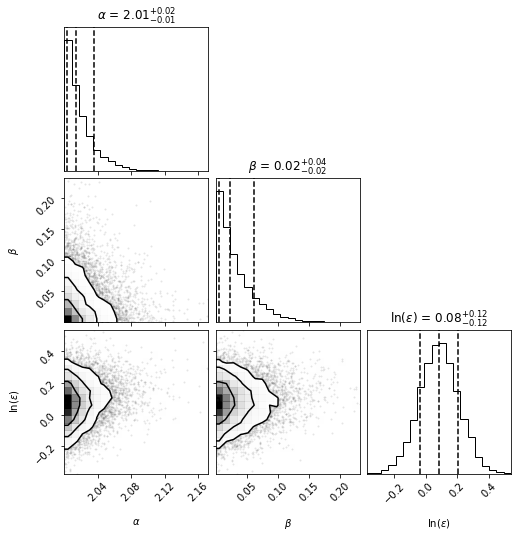

In [22]:
import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt
import re

# --- 1. PASTE DATA HERE ---
raw_text_data = """
Col. 1: Galaxy
Col. 2: Distance (Mpc)
Col. 3: MBH (Msun)
Col. 4: MBH lower (68%)
Col. 5: MBH upper (68%)
Col. 6: method
Col. 7: sigma (km/s)
Col. 8: sigma lower (68%)
Col. 9: sigma upper (68%)
Col. 10: log(LV/Lsun)
Col. 11: error in log(LV/Lsun)
Col. 12: log(L_3.6/Lsun) -- Spitzer 3.6 um, from Sani et al. 2011
Col. 13: error in log(L_3.6/Lsun)
Col. 14: Mbulge/Msun
Col. 15: radius of influence (arcsec)
Col. 16: Morphology -- (E)lliptical, S0, (S)piral
Col. 17: Profile -- (P)ower-law, (I)ntermediate, (C)ore, (U)ndetermined
Col. 18: Reff (V-band, arcsec)
Col. 19: Reff (i-band, arcsec) -- SDSS DR7, from Beifiori et al. 2012
Col. 20: Reff (3.6 um, arcsec) -- from Sani et al. 2011


MW	0.008	4.1e6	3.5e6	4.7e6	star	103	83	123	0	0	0	0	0	43	S	N/A	0	0	0
A1836	157.5	3.9e9	3.3e9	4.3e9	gas	288	274	302	11.26	0.06	0	0	0	0.27	E	C	0	17.61	0
A3565	54.4	1.4e9	1.2e9	1.7e9	gas	322	306	338	11.24	0.06	0	0	0	0.22	E	C	0	0	0
Circ	4.0	1.7e6	1.4e6	2.1e6	maser	158	140	176	0	0	10.31	0.02	0	0.02	S	N/A	0	0	10.83
IC1459	30.9	2.7e9	2.3e9	3.0e9	star	315	299	331	10.96	0.06	11.82	0.12	3.07e11	0.81	E	C	29.8	0	61.1
N221	0.73	2.6e6	2.1e6	3.1e6	star	75	72	78	8.52	0.02	8.95	0.25	7.62e8	0.57	E	I	38.6	0	28.8
N224	0.73	1.4e8	1.1e8	2.2e8	star	160	152	168	0	0	0	0	0	6.5	S	N/A	0	0	0	
N524	24.2	8.6e8	8.2e8	9.6e8	star	235	223	247	10.62	0.04	11.26	0.08	0	0.57	S0	C	0	0	26.8
N821	23.4	1.7e8	9.2e7	2.4e8	star	209	199	219	10.36	0.05	11.28	0.10	1.92e11	0.14	E	I	29.4	35.0	63.6
N1023	10.5	4.0e7	3.6e7	4.4e7	star	205	195	215	10.06	0.11	10.66	0.07	6.49e10	0.08	S0	P	0	0	24.0
N1194	55.5	6.8e7	6.5e7	7.1e7	maser	147.9	125.9	173.8	0	0	0	0	0	0.05	S0	U	0	0	0
N1277	73.0	1.7e10	1.4e10	2.0e10	star	333	316	350	0	0	0	0	2.88e10	1.9	S0	U	0	0	0
N1300	20.1	7.1e7	5.3e7	1.05e8	gas	218	208	228	0	0	10.55	0.13	0	0.07	S	N/A	0	0	85.4
N1316	21.0	1.7e8	1.4e8	2.0e8	star	226	215	237	11.18	0.05	12.06	0.32	0	0.14	E	I	65.8	0	93.0
N1332	22.7	1.5e9	1.3e9	1.7e9	star	328	312	344	10.16	0.05	0	0	0	0.54	S0	P	0	0	0	
N1374	19.6	5.9e8	5.4e8	6.4e8	star	174	165	183	10.10	0.05	0	0	5.54e10	0.89	E	C	25.4	0	0	
N1399	20.9	5.1e8	4.4e8	5.7e8	star	296	281	311	10.78	0.04	0	0	3.98e11	0.25	E	C	40.8	0	0
N1399	20.9	1.3e9	6.3e8	1.8e9	star	296	281	311	10.78	0.04	0	0	3.98e11	0.63	E	C	40.8	0	0
N1407	29.0	4.7e9	4.2e9	5.6e9	star	274	260	288	11.05	0.05	0	0	8.65e11 1.9	E	C	72.0	0	0	
N1550	53.0	3.8e9	3.4e9	4.2e9	star	289	275	303	10.88	0.05	0	0	0	0.76	E	I	0	0	0
N2273	26.8	7.8e6	7.4e6	8.2e6	maser	144.5	128.8	162.2	0	0	0	0	0	0.01	S	N/A	0	0	0
N2549	12.7	1.4e7	1.0e7	1.5e7	star	145	138	152	9.55	0.04	10.18	0.05	1.99e10	0.05	S0	P	36.1	0	11.6
N2787	7.5	4.1e7	3.6e7	4.5e7	gas	189	180	198	0	0	10.03	0.23	0	0.14	S0	P	0	0	15.7
N2960	75.3	1.21e7	1.16e7	1.26e7	maser	166.0	151.3	182.0	0	0	0	0	0	0.01	S	N/A	0	0	0
N3031	4.1	8.0e7	6.9e7	1.0e8	gas	143	136	150	0	0	10.93	0.12	0	0.85	S	N/A	0	94.6	127.3
N3091	52.7	3.7e9	3.5e9	3.8e9	star	307	292	322	11.02	0.05	0	0	0	0.66	E	C	30.7	0	0
N3115	9.5	8.9e8	6.2e8	1.4e9	star	230	219	241	10.34	0.02	10.86	0.04	1.57e11	1.6	S0	P	47.4	0	27.3
N3227	17.0	1.5e7	7.0e6	2.0e7	star	133	121	145	0	0	10.85	0.20	0	0.04	S	N/A	0	59.1	82.9
N3245	21.5	2.2e8	1.6e8	2.7e8	gas	205	195	215	0	0	10.47	0.08	7.00e10	0.21	S0	P	0	26.7	4.6
N3368	10.6	7.6e6	6.1e6	9.2e6	star	122	98	150	0	0	10.72	0.04	0	0.04	S	N/A	0	0	45.6
N3377	11.0	1.8e8	8.5e7	2.7e8	star	145	138	152	9.93	0.04	10.61	0.07	2.35e10	0.69	E	P	35.2	59.5	55.2
N3379	10.7	4.2e8	3.1e8	5.2e8	star	206	196	216	10.29	0.01	11.02	0.07	6.86e10	0.83	E	C	43.3	57.0	46.0
N3384	11.5	1.1e7	5.9e6	1.6e7	star	143	136	150	9.89	0.09	10.18	0.03	1.90e10	0.04	S0	P	21.2	37.7	4.4
N3393	53.6	3.3e7	3.1e7	3.5e7	maser	147.9	138.0	158.5	0	0	0	0	0	0.03	S	N/A	0	0	0
N3489	12.0	6.0e6	5.1e6	6.8e6	star	100	89	115	0	0	10.14	0.18	0	0.04	S0	U	0	0	4.6
N3585	20.6	3.3e8	2.7e8	4.8e8	star	213	203	223	10.66	0.08	11.04	0.25	1.60e11	0.31	S0	I	39.6	0	15.5
N3607	22.6	1.4e8	9.0e7	1.8e8	star	229	218	240	0	0	11.43	0.06	0	0.10	E	C	36.1	36.4	44.6
N3608	22.8	4.7e8	3.7e8	5.7e8	star	182	173	191	10.34	0.04	11.14	0.09	7.66e10	0.55	E	C	29.7	28.4	56.4
N3842	98.4	9.7e9	7.2e9	1.27e10	star	270	256	284	11.20	0.05	0	0	1.55e12	1.2	E	C	37.8	0	0
N3998	14.3	8.5e8	7.8e8	9.2e8	star	272	258	286	9.91	0.04	10.35	0.02	0	0.71	S0	P	0	20.4	4.7
N4026	13.4	1.8e8	1.5e8	2.4e8	star	180	171	189	9.73	0.08	10.32	0.07	2.81e10	0.37	S0	P	51.4	21.1	11.4
N4258	7.0	3.67e7	3.66e7	3.68e7	maser	115	105	125	0	0	10.88	0.03	0	0.35	S	N/A	0	135.8	111.7
N4261	32.6	5.3e8	4.2e8	6.4e8	gas	315	300	330	11.00	0.02	11.43	0.06	8.26e11	0.15	E	C	50.2	56.6	22.6
N4291	26.6	9.8e8	6.7e8	1.29e9	star	242	230	254	10.25	0.05	0	0	9.96e10	0.56	E	C	16.1	0	0
N4342	23.0	4.6e8	3.1e8	7.2e8	star	225	214	236	0	0	0	0	1.80e10	0.35	S0	P	0	7.6	0
N4374	18.5	9.2e8	8.4e8	1.02e9	gas	296	282	310	10.98	0.02	11.81	0.02	3.62e11	0.51	E	C	64.8	53.8	105.9
N4388	19.8	8.8e6	8.6e6	9.0e6	maser	107.2	100.0	114.8	0	0	0	0	0	0.03	S	N/A	0	0	0
N4459	16.0	7.0e7	5.6e7	8.3e7	gas	167	159	175	10.31	0.02	10.63	0.04	0	0.14	E	P	0	41.0	10.3
N4472	16.7	2.4e9	2.3e9	2.7e9	star	315	299	331	11.04	0.05	0	0	8.22e11	1.3	E	C	100.4	0	0
N4473	15.2	8.9e7	4.5e7	1.34e8	star	190	181	199	10.29	0.02	11.03	0.02	1.61e11	0.15	E	C	30.3	34.8	49.3
N4486	16.7	6.2e9	5.8e9	6.5e9	star	324	308	352	11.08	0.02	11.71	0.02	1.31e12	3.1	E	C	100.4	68.4	99.5
N4486A	18.4	1.4e7	8.9e6	1.9e7	star	111	106	116	9.48	0.02	10.21	0.03	0	0.06	E	P	0	5.8	7.2
N4526	16.5	4.73e8	4.60e8	4.86e8	gas	222	211	233	0	0	0	0	0	0.52	S0	U	0	45.6	0
N4564	15.9	8.8e7	6.4e7	1.12e8	star	162	154	170	0	0	10.60	0.05	4.66e10	0.19	S0	P	31.7	22.4	25.0
N4594	10.0	6.7e8	6.3e8	7.2e8	star	230	218	242	0	0	11.10	0.06	0	1.1	S	N/A	0	0	66.1
N4596	18.0	8.4e7	5.9e7	1.2e8	gas	136	130	142	0	0	10.77	0.02	0	0.22	S0	P	0	56.2	28.0
N4649	16.5	4.7e9	3.7e9	5.8e9	star	341	324	358	10.99	0.02	11.51	0.04	7.72e11	2.2	E	C	76.1	67.5	47.1
N4697	12.5	2.0e8	1.8e8	2.2e8	star	177	169	185	10.46	0.04	11.22	0.04	1.29e11	0.46	E	P	79.5	59.7	100.5
N4736	5.0	6.8e6	5.2e6	8.4e6	star	112	106	118	0	0	0	0	0	0.10	S	N/A	0	0	0
N4751  	27.7	1.4e9	1.3e9	1.5e9	star	355	337	373	10.26	0.05	0	0	0	0.36	E/S0	U	0	0	0
N4826	7.3	1.6e6	1.2e6	2.0e6	star	96	91	101	0	0	0	0	0	0.02	S	N/A	0	0	0
N4889   103.2   2.1e10  5.5e9   3.7e10  star    347     330     364	11.48	0.05	0	0	1.75e12	1.5	E	C	54.5	0	0
N5077	44.9	8.0e8	4.7e8	1.3e9	gas	222	211	233	10.75	0.05	11.56	0.10	3.66e11	0.32	E	C	25.0	0	29.2
N5128	4.1	5.9e7	4.9e7	7.0e7	star	150	143	157	10.60	0.03	11.13	0.11	0	0.60	S0/E	C	0	0	0
N5328	65.9	4.8e9	2.9e9	5.8e9	star	333	316	350	11.08	0.05	0	0	1.18e12	0.58	E	U	21.7	0	0
N5516	60.1	3.5e9	3.1e9	3.7e9	star	306	280	332	11.10	0.05	0	0	0	0.55	E	C	0	0	0
N5576	25.7	1.7e8	1.3e8	2.0e8	star	183	174	192	10.39	0.05	11.22	0.06	9.58e10	0.18	E	C	28.9	49.4	34.3
N5845	25.9	4.9e8	3.3e8	6.4e8	star	234	223	245	9.75	0.05	10.54	0.01	3.36e10	0.31	E	P	3.3	4.3	3.7
N6086	139.1	3.8e9	2.6e9	5.5e9	star	318	302	334	11.23	0.05	0	0	1.43e12	0.24	E	C	36.8	0	0
N6251	106.0	6.0e8	4.0e8	8.0e8	gas	290	276	304	0	0	12.07	0.08	5.60e11	0.06	E	P	0	0	42.4
N6264	145.4	3.03e7	2.99e7	3.08e7	maser	158.5	144.5	173.8	0	0	0	0	0	0.01	S	N/A	0	0	0
N6323	110.5	9.8e6	9.7e6	9.9e6	maser	158.5	134.9	186.2	0	0	0	0	0	0.003	S	N/A	0	0	0
N6861	28.9	2.1e9	1.9e9	2.3e9	star	389	370	408	10.54	0.05	0	0	0	0.43	E/S0	U	22.8	0	0
N7052	70.9	4.0e8	2.4e8	6.8e8	gas	266	253	279	10.92	0.04	11.82	0.06	3.50e11	0.07	E	C	40.5	0	39.3
N7582	22.3	5.5e7	4.4e7	7.1e7	gas	156	137	175	0	0	11.06	0.18	0	0.09	S	N/A	0	0	86.4
N7619	53.9	2.6e9	2.3e9	3.5e9	star	313	297	329	11.07	0.05	0	0	0	0.44	E	C	34.3	0	0
N7768	112.8	1.3e9	9.0e8	1.8e9	star	257	244	270	11.09	0.05	0	0	1.16e12	0.14	E	C	0	0	0
U3789	48.4	1.08e7	1.03e7	1.14e7	maser	107.2	95.5	120.2	0	0	0	0	0	0.02	S	N/A	0	0	0
"""

# --- 2. THE CORRECTED PARSER ---
data_list = []
number_pattern = r"[-+]?\d*\.\d+|\d+"

for line in raw_text_data.splitlines():
    numbers = re.findall(number_pattern, line)
    
    # Berkeley columns: [4]M_BH, [5]M_BH_err, [6]sig_e, [7]sig_e_err
    if len(numbers) >= 8:
        try:
            # We must use float conversion on the specific indices
            row = [float(numbers[4]), float(numbers[5]), float(numbers[6]), float(numbers[7])]
            if row[0] > 0 and row[2] > 0:
                data_list.append(row)
        except (ValueError, IndexError):
            continue

data = np.array(data_list)
print(f"Success! Loaded {len(data)} galaxies.")

# --- 3. LOG CONVERSION ---
x = np.log10(data[:, 2])      # log10(sigma)
y = np.log10(data[:, 0])      # log10(M_bh)
x_err = 0.434 * (data[:, 3] / data[:, 2])
y_err = 0.434 * (data[:, 1] / data[:, 0])

# --- 4. MCMC FUNCTIONS ---
def log_probability(theta, x, y, x_err, y_err):
    alpha, beta, log_eps = theta
    # Broaden priors slightly to ensure walkers don't hit the 'walls'
    if not (2.0 < alpha < 15.0 and 0.0 < beta < 10.0 and -10.0 < log_eps < 2.0):
        return -np.inf
    sigma2 = y_err**2 + (beta**2 * x_err**2) + np.exp(log_eps)**2
    return -0.5 * np.sum((y - (alpha + beta * x))**2 / sigma2 + np.log(2 * np.pi * sigma2))

# --- 5. RUN MCMC ---
ndim, nwalkers = 3, 32
# Better starting point for M-Sigma: Alpha ~ 8, Beta ~ 5
pos = np.array([8.1, 4.5, -1.0]) + 1e-4 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, x_err, y_err))

print("Sampling...")
sampler.run_mcmc(pos, 6000, progress=True)

# --- 6. PLOTS ---
samples = sampler.get_chain(discard=1500, thin=15, flat=True)
# This should now produce beautiful Gaussian 'bell' curves
corner.corner(samples, labels=[r"$\alpha$", r"$\beta$", r"$\ln(\epsilon)$"], 
              show_titles=True, quantiles=[0.16, 0.5, 0.84])
plt.show()

Sampling with 76 galaxies...


100%|██████████| 8000/8000 [00:06<00:00, 1299.33it/s]



--- MCMC Results ---
Intercept (alpha): 4.58 (+0.30/-0.34)
Slope (beta):     1.72 (+0.14/-0.13)
ln(epsilon):      -5.78 (+2.84/-2.86)


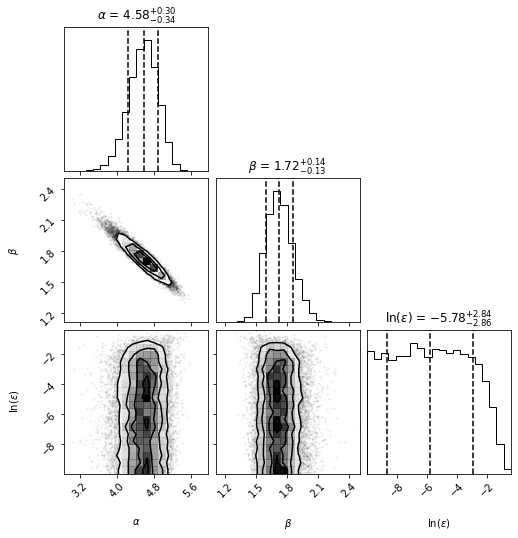

In [26]:
import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt
import re

# --- 1. DATA INPUT ---
# Copy the entire text from the Berkeley site and paste it below
raw_text_data = """
Col. 1: Galaxy
Col. 2: Distance (Mpc)
Col. 3: MBH (Msun)
Col. 4: MBH lower (68%)
Col. 5: MBH upper (68%)
Col. 6: method
Col. 7: sigma (km/s)
Col. 8: sigma lower (68%)
Col. 9: sigma upper (68%)
Col. 10: log(LV/Lsun)
Col. 11: error in log(LV/Lsun)
Col. 12: log(L_3.6/Lsun) -- Spitzer 3.6 um, from Sani et al. 2011
Col. 13: error in log(L_3.6/Lsun)
Col. 14: Mbulge/Msun
Col. 15: radius of influence (arcsec)
Col. 16: Morphology -- (E)lliptical, S0, (S)piral
Col. 17: Profile -- (P)ower-law, (I)ntermediate, (C)ore, (U)ndetermined
Col. 18: Reff (V-band, arcsec)
Col. 19: Reff (i-band, arcsec) -- SDSS DR7, from Beifiori et al. 2012
Col. 20: Reff (3.6 um, arcsec) -- from Sani et al. 2011


MW	0.008	4.1e6	3.5e6	4.7e6	star	103	83	123	0	0	0	0	0	43	S	N/A	0	0	0
A1836	157.5	3.9e9	3.3e9	4.3e9	gas	288	274	302	11.26	0.06	0	0	0	0.27	E	C	0	17.61	0
A3565	54.4	1.4e9	1.2e9	1.7e9	gas	322	306	338	11.24	0.06	0	0	0	0.22	E	C	0	0	0
Circ	4.0	1.7e6	1.4e6	2.1e6	maser	158	140	176	0	0	10.31	0.02	0	0.02	S	N/A	0	0	10.83
IC1459	30.9	2.7e9	2.3e9	3.0e9	star	315	299	331	10.96	0.06	11.82	0.12	3.07e11	0.81	E	C	29.8	0	61.1
N221	0.73	2.6e6	2.1e6	3.1e6	star	75	72	78	8.52	0.02	8.95	0.25	7.62e8	0.57	E	I	38.6	0	28.8
N224	0.73	1.4e8	1.1e8	2.2e8	star	160	152	168	0	0	0	0	0	6.5	S	N/A	0	0	0	
N524	24.2	8.6e8	8.2e8	9.6e8	star	235	223	247	10.62	0.04	11.26	0.08	0	0.57	S0	C	0	0	26.8
N821	23.4	1.7e8	9.2e7	2.4e8	star	209	199	219	10.36	0.05	11.28	0.10	1.92e11	0.14	E	I	29.4	35.0	63.6
N1023	10.5	4.0e7	3.6e7	4.4e7	star	205	195	215	10.06	0.11	10.66	0.07	6.49e10	0.08	S0	P	0	0	24.0
N1194	55.5	6.8e7	6.5e7	7.1e7	maser	147.9	125.9	173.8	0	0	0	0	0	0.05	S0	U	0	0	0
N1277	73.0	1.7e10	1.4e10	2.0e10	star	333	316	350	0	0	0	0	2.88e10	1.9	S0	U	0	0	0
N1300	20.1	7.1e7	5.3e7	1.05e8	gas	218	208	228	0	0	10.55	0.13	0	0.07	S	N/A	0	0	85.4
N1316	21.0	1.7e8	1.4e8	2.0e8	star	226	215	237	11.18	0.05	12.06	0.32	0	0.14	E	I	65.8	0	93.0
N1332	22.7	1.5e9	1.3e9	1.7e9	star	328	312	344	10.16	0.05	0	0	0	0.54	S0	P	0	0	0	
N1374	19.6	5.9e8	5.4e8	6.4e8	star	174	165	183	10.10	0.05	0	0	5.54e10	0.89	E	C	25.4	0	0	
N1399	20.9	5.1e8	4.4e8	5.7e8	star	296	281	311	10.78	0.04	0	0	3.98e11	0.25	E	C	40.8	0	0
N1399	20.9	1.3e9	6.3e8	1.8e9	star	296	281	311	10.78	0.04	0	0	3.98e11	0.63	E	C	40.8	0	0
N1407	29.0	4.7e9	4.2e9	5.6e9	star	274	260	288	11.05	0.05	0	0	8.65e11 1.9	E	C	72.0	0	0	
N1550	53.0	3.8e9	3.4e9	4.2e9	star	289	275	303	10.88	0.05	0	0	0	0.76	E	I	0	0	0
N2273	26.8	7.8e6	7.4e6	8.2e6	maser	144.5	128.8	162.2	0	0	0	0	0	0.01	S	N/A	0	0	0
N2549	12.7	1.4e7	1.0e7	1.5e7	star	145	138	152	9.55	0.04	10.18	0.05	1.99e10	0.05	S0	P	36.1	0	11.6
N2787	7.5	4.1e7	3.6e7	4.5e7	gas	189	180	198	0	0	10.03	0.23	0	0.14	S0	P	0	0	15.7
N2960	75.3	1.21e7	1.16e7	1.26e7	maser	166.0	151.3	182.0	0	0	0	0	0	0.01	S	N/A	0	0	0
N3031	4.1	8.0e7	6.9e7	1.0e8	gas	143	136	150	0	0	10.93	0.12	0	0.85	S	N/A	0	94.6	127.3
N3091	52.7	3.7e9	3.5e9	3.8e9	star	307	292	322	11.02	0.05	0	0	0	0.66	E	C	30.7	0	0
N3115	9.5	8.9e8	6.2e8	1.4e9	star	230	219	241	10.34	0.02	10.86	0.04	1.57e11	1.6	S0	P	47.4	0	27.3
N3227	17.0	1.5e7	7.0e6	2.0e7	star	133	121	145	0	0	10.85	0.20	0	0.04	S	N/A	0	59.1	82.9
N3245	21.5	2.2e8	1.6e8	2.7e8	gas	205	195	215	0	0	10.47	0.08	7.00e10	0.21	S0	P	0	26.7	4.6
N3368	10.6	7.6e6	6.1e6	9.2e6	star	122	98	150	0	0	10.72	0.04	0	0.04	S	N/A	0	0	45.6
N3377	11.0	1.8e8	8.5e7	2.7e8	star	145	138	152	9.93	0.04	10.61	0.07	2.35e10	0.69	E	P	35.2	59.5	55.2
N3379	10.7	4.2e8	3.1e8	5.2e8	star	206	196	216	10.29	0.01	11.02	0.07	6.86e10	0.83	E	C	43.3	57.0	46.0
N3384	11.5	1.1e7	5.9e6	1.6e7	star	143	136	150	9.89	0.09	10.18	0.03	1.90e10	0.04	S0	P	21.2	37.7	4.4
N3393	53.6	3.3e7	3.1e7	3.5e7	maser	147.9	138.0	158.5	0	0	0	0	0	0.03	S	N/A	0	0	0
N3489	12.0	6.0e6	5.1e6	6.8e6	star	100	89	115	0	0	10.14	0.18	0	0.04	S0	U	0	0	4.6
N3585	20.6	3.3e8	2.7e8	4.8e8	star	213	203	223	10.66	0.08	11.04	0.25	1.60e11	0.31	S0	I	39.6	0	15.5
N3607	22.6	1.4e8	9.0e7	1.8e8	star	229	218	240	0	0	11.43	0.06	0	0.10	E	C	36.1	36.4	44.6
N3608	22.8	4.7e8	3.7e8	5.7e8	star	182	173	191	10.34	0.04	11.14	0.09	7.66e10	0.55	E	C	29.7	28.4	56.4
N3842	98.4	9.7e9	7.2e9	1.27e10	star	270	256	284	11.20	0.05	0	0	1.55e12	1.2	E	C	37.8	0	0
N3998	14.3	8.5e8	7.8e8	9.2e8	star	272	258	286	9.91	0.04	10.35	0.02	0	0.71	S0	P	0	20.4	4.7
N4026	13.4	1.8e8	1.5e8	2.4e8	star	180	171	189	9.73	0.08	10.32	0.07	2.81e10	0.37	S0	P	51.4	21.1	11.4
N4258	7.0	3.67e7	3.66e7	3.68e7	maser	115	105	125	0	0	10.88	0.03	0	0.35	S	N/A	0	135.8	111.7
N4261	32.6	5.3e8	4.2e8	6.4e8	gas	315	300	330	11.00	0.02	11.43	0.06	8.26e11	0.15	E	C	50.2	56.6	22.6
N4291	26.6	9.8e8	6.7e8	1.29e9	star	242	230	254	10.25	0.05	0	0	9.96e10	0.56	E	C	16.1	0	0
N4342	23.0	4.6e8	3.1e8	7.2e8	star	225	214	236	0	0	0	0	1.80e10	0.35	S0	P	0	7.6	0
N4374	18.5	9.2e8	8.4e8	1.02e9	gas	296	282	310	10.98	0.02	11.81	0.02	3.62e11	0.51	E	C	64.8	53.8	105.9
N4388	19.8	8.8e6	8.6e6	9.0e6	maser	107.2	100.0	114.8	0	0	0	0	0	0.03	S	N/A	0	0	0
N4459	16.0	7.0e7	5.6e7	8.3e7	gas	167	159	175	10.31	0.02	10.63	0.04	0	0.14	E	P	0	41.0	10.3
N4472	16.7	2.4e9	2.3e9	2.7e9	star	315	299	331	11.04	0.05	0	0	8.22e11	1.3	E	C	100.4	0	0
N4473	15.2	8.9e7	4.5e7	1.34e8	star	190	181	199	10.29	0.02	11.03	0.02	1.61e11	0.15	E	C	30.3	34.8	49.3
N4486	16.7	6.2e9	5.8e9	6.5e9	star	324	308	352	11.08	0.02	11.71	0.02	1.31e12	3.1	E	C	100.4	68.4	99.5
N4486A	18.4	1.4e7	8.9e6	1.9e7	star	111	106	116	9.48	0.02	10.21	0.03	0	0.06	E	P	0	5.8	7.2
N4526	16.5	4.73e8	4.60e8	4.86e8	gas	222	211	233	0	0	0	0	0	0.52	S0	U	0	45.6	0
N4564	15.9	8.8e7	6.4e7	1.12e8	star	162	154	170	0	0	10.60	0.05	4.66e10	0.19	S0	P	31.7	22.4	25.0
N4594	10.0	6.7e8	6.3e8	7.2e8	star	230	218	242	0	0	11.10	0.06	0	1.1	S	N/A	0	0	66.1
N4596	18.0	8.4e7	5.9e7	1.2e8	gas	136	130	142	0	0	10.77	0.02	0	0.22	S0	P	0	56.2	28.0
N4649	16.5	4.7e9	3.7e9	5.8e9	star	341	324	358	10.99	0.02	11.51	0.04	7.72e11	2.2	E	C	76.1	67.5	47.1
N4697	12.5	2.0e8	1.8e8	2.2e8	star	177	169	185	10.46	0.04	11.22	0.04	1.29e11	0.46	E	P	79.5	59.7	100.5
N4736	5.0	6.8e6	5.2e6	8.4e6	star	112	106	118	0	0	0	0	0	0.10	S	N/A	0	0	0
N4751  	27.7	1.4e9	1.3e9	1.5e9	star	355	337	373	10.26	0.05	0	0	0	0.36	E/S0	U	0	0	0
N4826	7.3	1.6e6	1.2e6	2.0e6	star	96	91	101	0	0	0	0	0	0.02	S	N/A	0	0	0
N4889   103.2   2.1e10  5.5e9   3.7e10  star    347     330     364	11.48	0.05	0	0	1.75e12	1.5	E	C	54.5	0	0
N5077	44.9	8.0e8	4.7e8	1.3e9	gas	222	211	233	10.75	0.05	11.56	0.10	3.66e11	0.32	E	C	25.0	0	29.2
N5128	4.1	5.9e7	4.9e7	7.0e7	star	150	143	157	10.60	0.03	11.13	0.11	0	0.60	S0/E	C	0	0	0
N5328	65.9	4.8e9	2.9e9	5.8e9	star	333	316	350	11.08	0.05	0	0	1.18e12	0.58	E	U	21.7	0	0
N5516	60.1	3.5e9	3.1e9	3.7e9	star	306	280	332	11.10	0.05	0	0	0	0.55	E	C	0	0	0
N5576	25.7	1.7e8	1.3e8	2.0e8	star	183	174	192	10.39	0.05	11.22	0.06	9.58e10	0.18	E	C	28.9	49.4	34.3
N5845	25.9	4.9e8	3.3e8	6.4e8	star	234	223	245	9.75	0.05	10.54	0.01	3.36e10	0.31	E	P	3.3	4.3	3.7
N6086	139.1	3.8e9	2.6e9	5.5e9	star	318	302	334	11.23	0.05	0	0	1.43e12	0.24	E	C	36.8	0	0
N6251	106.0	6.0e8	4.0e8	8.0e8	gas	290	276	304	0	0	12.07	0.08	5.60e11	0.06	E	P	0	0	42.4
N6264	145.4	3.03e7	2.99e7	3.08e7	maser	158.5	144.5	173.8	0	0	0	0	0	0.01	S	N/A	0	0	0
N6323	110.5	9.8e6	9.7e6	9.9e6	maser	158.5	134.9	186.2	0	0	0	0	0	0.003	S	N/A	0	0	0
N6861	28.9	2.1e9	1.9e9	2.3e9	star	389	370	408	10.54	0.05	0	0	0	0.43	E/S0	U	22.8	0	0
N7052	70.9	4.0e8	2.4e8	6.8e8	gas	266	253	279	10.92	0.04	11.82	0.06	3.50e11	0.07	E	C	40.5	0	39.3
N7582	22.3	5.5e7	4.4e7	7.1e7	gas	156	137	175	0	0	11.06	0.18	0	0.09	S	N/A	0	0	86.4
N7619	53.9	2.6e9	2.3e9	3.5e9	star	313	297	329	11.07	0.05	0	0	0	0.44	E	C	34.3	0	0
N7768	112.8	1.3e9	9.0e8	1.8e9	star	257	244	270	11.09	0.05	0	0	1.16e12	0.14	E	C	0	0	0
U3789	48.4	1.08e7	1.03e7	1.14e7	maser	107.2	95.5	120.2	0	0	0	0	0	0.02	S	N/A	0	0	0
"""

# --- 2. ROBUST PARSER ---
data_list = []
# Regex finds numbers including scientific notation (e.g., 1.2e8)
number_pattern = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"

for line in raw_text_data.splitlines():
    numbers = re.findall(number_pattern, line)
    # Berkeley columns: [4]M_BH, [5]M_BH_err, [6]sig_e, [7]sig_e_err
    if len(numbers) >= 8:
        try:
            row = [float(numbers[4]), float(numbers[5]), float(numbers[6]), float(numbers[7])]
            # Sanity check for physical Black Hole and Dispersion values
            if row[0] > 1e3 and row[2] > 10: 
                data_list.append(row)
        except (ValueError, IndexError):
            continue

data = np.array(data_list)
if data.size == 0:
    raise ValueError("The data array is still empty. Ensure you pasted the numerical table.")

# --- 3. LOG CONVERSION & ERRORS ---
x = np.log10(data[:, 2])      # log10(sigma)
y = np.log10(data[:, 0])      # log10(M_bh)
x_err = 0.434 * (data[:, 3] / data[:, 2])
y_err = 0.434 * (data[:, 1] / data[:, 0])

# --- 4. MODEL WITH INTRINSIC SCATTER ---
def log_probability(theta, x, y, x_err, y_err):
    alpha, beta, log_eps = theta
    
    # Priors for Intercept, Slope, and Log Intrinsic Scatter
    if not (2.0 < alpha < 15.0 and 0.0 < beta < 10.0 and -10.0 < log_eps < 2.0):
        return -np.inf
    
    epsilon = np.exp(log_eps)
    # Add measurement errors and intrinsic scatter in quadrature
    sigma2 = y_err**2 + (beta**2 * x_err**2) + epsilon**2
    
    model = alpha + beta * x
    return -0.5 * np.sum((y - model)**2 / sigma2 + np.log(2 * np.pi * sigma2))

# --- 5. MCMC SAMPLING ---
ndim, nwalkers = 3, 32
pos = np.array([8.1, 4.4, -1.0]) + 1e-4 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, x_err, y_err))

print(f"Sampling with {len(data)} galaxies...")
sampler.run_mcmc(pos, 8000, progress=True)

# --- 6. RESULTS & VISUALIZATION ---
samples = sampler.get_chain(discard=2000, thin=15, flat=True)

# Calculate 16th, 50th, and 84th percentiles for credible intervals
alpha_res, beta_res, log_eps_res = map(
    lambda v: (v[1], v[2]-v[1], v[1]-v[0]),
    zip(*np.percentile(samples, [16, 50, 84], axis=0))
)

print(f"\n--- MCMC Results ---")
print(f"Intercept (alpha): {alpha_res[0]:.2f} (+{alpha_res[1]:.2f}/-{alpha_res[2]:.2f})")
print(f"Slope (beta):     {beta_res[0]:.2f} (+{beta_res[1]:.2f}/-{beta_res[2]:.2f})")
print(f"ln(epsilon):      {log_eps_res[0]:.2f} (+{log_eps_res[1]:.2f}/-{log_eps_res[2]:.2f})")

corner.corner(samples, labels=[r"$\alpha$", r"$\beta$", r"$\ln(\epsilon)$"], 
              show_titles=True, quantiles=[0.16, 0.5, 0.84])
plt.show()